## Simulation of ABC Model - (Auger, Bimolecular, SRH Trapping)

In [5]:
from globalfit_functions import *
import matplotlib.pyplot as plt

#### Define Simulation Parameters

In [6]:
#Time between 0 and 100 microseconds, logarithmically spaced
time = (jnp.logspace(0, np.log10(100001), 1000))-1

#Initial Carrier Densities
n0s = [1e14, 1e15, 1e16, 1e17, 1e18]

#Rate Constants
A = 1e-4
B = 1e-19
C = 1e-37
bkg = 1e-5 #Background Signal

time_label = 'Time (ns)'
qfls_label = 'QFLS (eV)'
PL_label = 'PL (a.u.)'
diff_decay_label = fr'$\tau_{{diff}}$ (s)'
diff_const_label = fr'$k_{{diff}}$ ($cm^{{3}}s^{{-1}})$'


#### Simulate TRPL Decays and Differential Transformations

Simulating for n0 = 1.00e+14
(1000,)
Simulating for n0 = 1.00e+15
(1000,)
Simulating for n0 = 1.00e+16
(1000,)
Simulating for n0 = 1.00e+17
(1000,)
Simulating for n0 = 1.00e+18
(1000,)


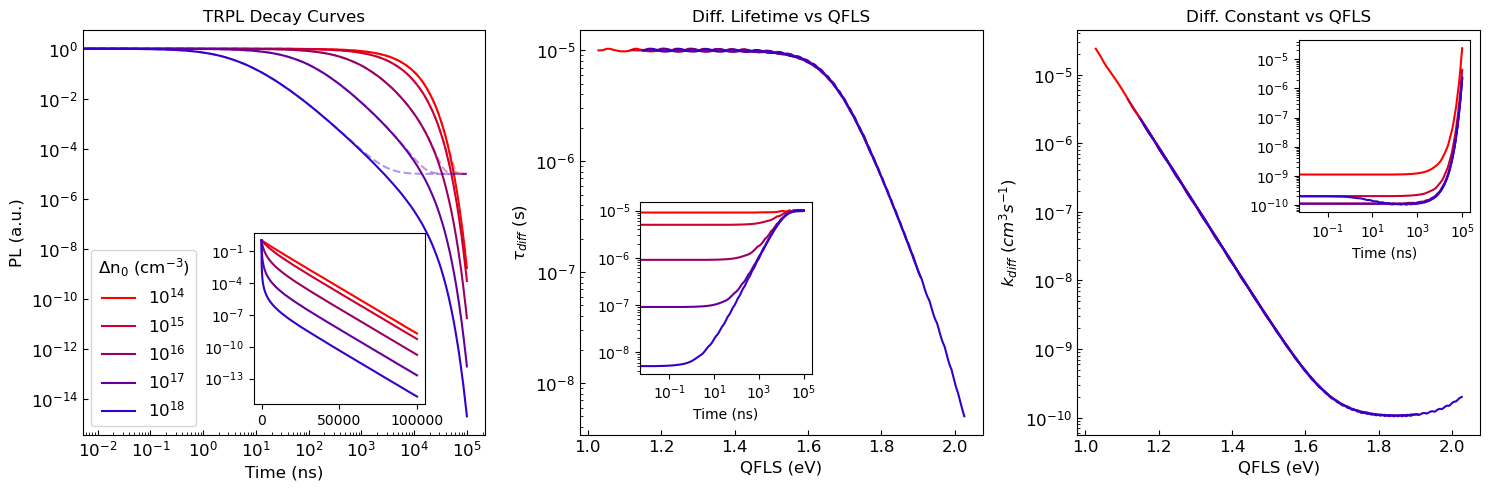

In [7]:
fig, ax = plt.subplots(1,3 , figsize=(15,5))

ax_inset_1 = ax[0].inset_axes([0.425, 0.075, 0.425, 0.425])
ax_inset_2 = ax[1].inset_axes([0.15, 0.15, 0.425, 0.425])
ax_inset_3 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])

for i, n in enumerate(n0s):
    print(f'Simulating for n0 = {n:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(n0s))

    trpl, n_e = TRPL_ABC_Model(time, n, A, B, C, 0)
    print(trpl.shape)
    trpl_with_bkg = TRPL_ABC_Model(time, n, A, B, C, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(n))}}}$')
    ax_inset_1.semilogy(time, trpl/trpl[0], color=color)
    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n)
    qfls = relative_QFLS(trpl, n0=n, n0_max=n0s[0], eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_2.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_3.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'$\Delta$n$_0$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax_inset_3.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()

#### Contributions of Each Physical Process

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
C:\Users\barne\AppData\Local\Temp\ipykernel_44732\3005521885.py:19: SyntaxWarning: invalid escape sequence '\D'
  ax[i//2].set_title(f'Decay Contributions for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')
C:\Users\barne\AppData\Local\Temp\ipykernel_44732\3005521885.py:22: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[i//2].set_xlim(0,1e5)


Simulating for n0 = 1.00e+14
Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+18


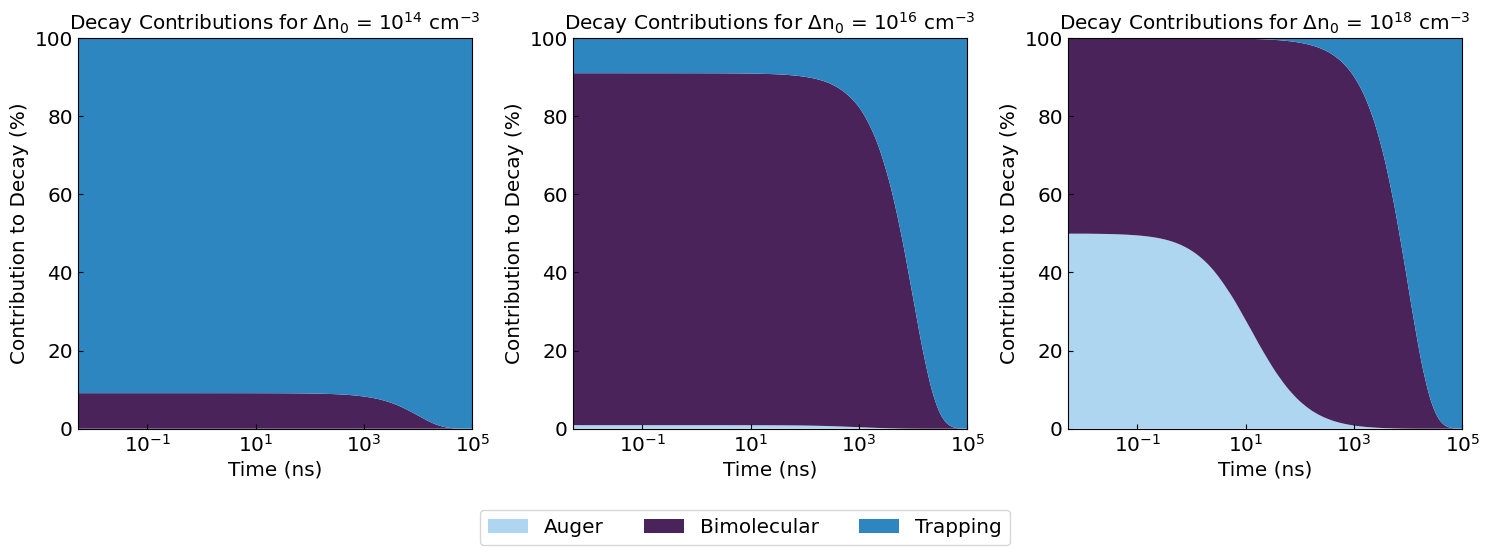

In [8]:
planner2_colors = ['#AED6F1', '#4A235A', '#2E86C1']
fig, ax = plt.subplots(1,3 , figsize=(15,5))
for i, n in enumerate(n0s):
    if i % 2 == 0:
        print(f'Simulating for n0 = {n:.2e}')

        trpl, n_e = TRPL_ABC_Model(time, n, A, B, C, 0)
        auger = C * n_e**3
        bimolecular = B * n_e**2
        trapping = A * n_e

        total = auger + bimolecular + trapping

        auger_norm, bimolecular_norm, trapping_norm = [100*x/total for x in [auger, bimolecular, trapping]]

        ax[i//2].stackplot(time, auger_norm, bimolecular_norm, trapping_norm, colors=planner2_colors, labels=['Auger', 'Bimolecular', 'Trapping'])
        ax[i//2].set_xlabel(time_label, fontsize='x-large')
        ax[i//2].set_ylabel('Contribution to Decay (%)', fontsize='x-large')
        ax[i//2].set_title(f'Decay Contributions for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')
        ax[i//2].set_ylim(0,100)
        ax[i//2].set_xscale('log')
        ax[i//2].set_xlim(0,1e5)
        ax[i//2].tick_params(axis='both', which='major', labelsize='x-large', direction='in')
fig.legend(['Auger', 'Bimolecular', 'Trapping'], fontsize='x-large', ncols=3, loc='upper center', bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()